# Importing Libraries

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# Load Dataset

In [4]:
df = pd.read_csv("creditcard.csv")
df = df.drop_duplicates()


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


# Missing values

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df.duplicated().sum()

0

# class Distribution

In [12]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

# Fraud percentage

In [14]:
fraud_percentage = df['Class'].value_counts(normalize=True)[1] * 100
print(f"Fraud Percentage: {fraud_percentage:.4f}%")


Fraud Percentage: 0.1667%


# Removed duplicates

In [16]:
df = df.drop_duplicates()

df.duplicated().sum()


0

In [17]:
df.shape


(283726, 31)

# Recalculate fraud percentage

In [19]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

# Exploratory Data Analysis

## 1 . Analyze Transaction Amount - EDA
- Are fraud transactions usually high value or small value?
- Is there separation between fraud and normal?

In [22]:
# Summary statistics for fraud transactions
df[df['Class']==1]['Amount'].describe()


count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [23]:
# Summary statistics for normal transactions
df[df['Class']==0]['Amount'].describe()


count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

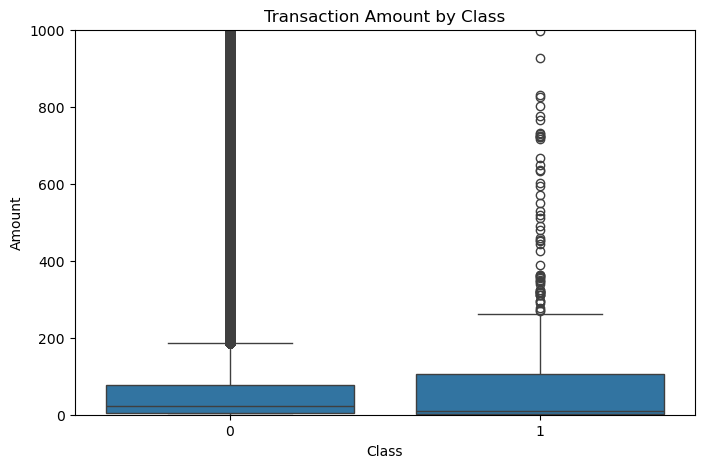

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 1000)  # zoom to see pattern clearly
plt.title("Transaction Amount by Class")
plt.show()


## 2 . Analyze Time Pattern - EDA

In [26]:
df['Hour'] = df['Time'] / 3600 #creating hour feature

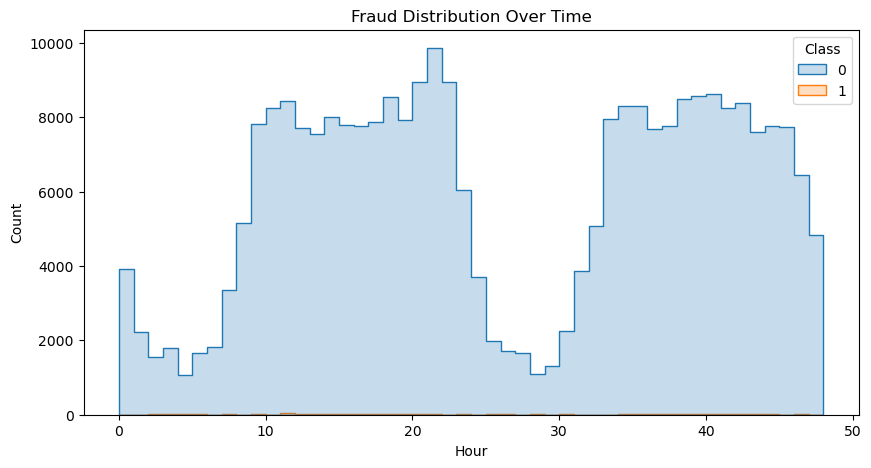

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Hour', hue='Class', bins=48, element="step")
plt.title("Fraud Distribution Over Time")
plt.show()


## 3 . Correlation with Target - EDA

In [29]:
correlations = df.corr()['Class'].sort_values(ascending=False)
print(correlations.head(10))
print(correlations.tail(10))


Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


## **Final EDA observation from above**
- Dataset is highly imbalanced.
- Fraud amounts are generally small to medium.
- No obvious time-based fraud pattern.
- Certain PCA components strongly correlate with fraud.
- Fraud detection will require pattern learning, not rule-based logic.

# Model Preparation

## Feature Scaling

In [33]:
df.drop('Hour', axis=1, inplace=True) # cleanign hour cuz its created only for analysis

### **Why scale only Time and Amount?**
Because:
- V1–V28 are already PCA-transformed and standardized.
- Time and Amount are not scaled.
- Models like Logistic Regression are sensitive to feature scale.

In [35]:
from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

df['scaled_amount'] = amount_scaler.fit_transform(df[['Amount']])
df['scaled_time'] = time_scaler.fit_transform(df[['Time']])

df.drop(['Time','Amount'], axis=1, inplace=True)

scaled_amount = df.pop('scaled_amount')
scaled_time = df.pop('scaled_time')

df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)


In [36]:
print(df.columns)


Index(['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
       'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
       'V27', 'V28', 'Class'],
      dtype='object')


In [37]:
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244200,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342584,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.158900,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.139886,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073813,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Train–Test Split

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [40]:
print("Training Fraud Ratio:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Fraud Ratio:")
print(y_test.value_counts(normalize=True) * 100)


Training Fraud Ratio:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing Fraud Ratio:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


## Handle Imbalance (SMOTE)

In [42]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())


Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


-------

###  **Before SMOTE:**
- Normal: 226,602
- Fraud: 378
- After SMOTE:
- Normal: 226,602
- Fraud: 226,602
- Perfect 50–50 balance.

## **Logistic Regression(Baseline Model )**

In [46]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)


## Evaluation

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC: 0.923788496324216


In [49]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)


[[55172  1479]
 [   12    83]]


- TN = 55,172
- FP = 1,479
- FN = 12
- TP = 83

-------

### **Fraud Class (Class = 1)**

- **From classification report:**
  - Precision = 0.05
  - Recall = 0.87
  - F1-score = 0.10
  - Support = 95
  - ROC-AUC = 0.9237

### Model Evaluation – Key Observations

- **Recall (Fraud Class) = 0.87**
  - Detected 83 out of 95 fraud cases.
  - Only 12 fraud transactions were missed.
  - Good for minimizing financial loss.

- **Precision (Fraud Class) = 0.05**
  - Only 5% of predicted fraud cases are actually fraud.
  - For every 100 fraud alerts, ~95 are false positives.
  - High operational cost and poor customer experience.

- **Accuracy = 97%**
  - Misleading due to extreme class imbalance (0.1667% fraud).
  - Not a reliable metric for fraud detection problems.

- **ROC-AUC = 0.92**
  - Strong overall ability to separate fraud from normal transactions.
  - Indicates good ranking performance.
  - Default threshold (0.5) is not optimized.



### Business Interpretation

- Model prioritizes **high recall over precision**.
- Suitable for aggressive fraud detection strategies.
- Not ideal for real-world deployment without further tuning.
- Next steps: optimize probability threshold and test advanced models (Random Forest, XGBoost).


-----
## **Biggest Faults**
- Precision is terrible (0.05)
- Too many false positives
- First we fix the decision threshold.

## Threshold Tuning

In [56]:
y_pred_lr = lr.predict(X_test)


In [57]:
y_probs = lr.predict_proba(X_test)[:, 1]


In [58]:
import numpy as np

threshold = 0.9

y_pred_custom = (y_probs >= threshold).astype(int)


In [59]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_custom))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.21      0.84      0.34        95

    accuracy                           0.99     56746
   macro avg       0.61      0.92      0.67     56746
weighted avg       1.00      0.99      1.00     56746

Confusion Matrix:
[[56351   300]
 [   15    80]]


------------
### Threshold Tuning Summary

**Threshold = 0.5**
- Precision (Fraud): 0.05  
- Recall (Fraud): 0.87  
- False Positives: 1479  
- Too many false alerts.

**Threshold = 0.9**
- Precision (Fraud): 0.21  
- Recall (Fraud): 0.84  
- False Positives: 300  

### Key Takeaway
- False positives reduced drastically.
- Slight drop in recall.
- Better balance for real-world fraud detection.
- Model was strong; threshold selection was the issue.


----------------------------
## **Random Forest**

In [62]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)


In [63]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8841575704985929
Confusion Matrix:
[[56645     6]
 [   22    73]]


- TN = 56,645
- FP = 6
- FN = 22
- TP = 73
### **Fraud Class Metrics**
- Precision = 0.92
- Recall = 0.77
- F1-score = 0.84
- ROC-AUC = 0.88
### Comparison Insight

- Much higher precision than Logistic Regression.
- Drastically reduced false positives.
- Slight drop in recall.
- More practical for real-world deployment.

----------------------

## Feature Importance (Random Forest)

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = rf.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


,Feature,Importance
15,V14,0.214008
13,V12,0.149240
5,V4,0.095342
11,V10,0.087944
18,V17,0.073859
12,V11,0.068111
4,V3,0.046497
8,V7,0.029722
3,V2,0.027570
17,V16,0.026243


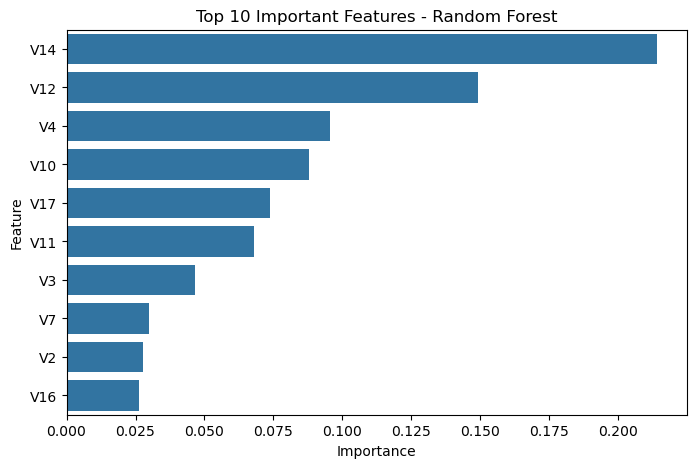

In [68]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)
plt.title("Top 10 Important Features - Random Forest")
plt.show()


### Feature Importance – Random Forest

Top Important Features:
- V14 (highest importance)
- V12
- V4
- V10
- V17

### Key Insights

- Fraud detection is primarily driven by PCA-transformed transaction patterns.
- Transaction amount and time are not among the top influencing features.
- The model captures complex behavioral signals rather than simple rules.
- Indicates strong nonlinear pattern learning by Random Forest.


-------------------------

## Financial Impact Calculation
- How much fraud was prevented?
- What is estimated loss saved?

In [72]:
# Get original amounts from test set (before scaling)
original_test = pd.read_csv("creditcard.csv").drop_duplicates()

# Align test indices
original_test = original_test.loc[y_test.index]

# Fraud detected correctly
true_fraud_detected = original_test[(y_test == 1) & (y_pred_rf == 1)]

money_saved = true_fraud_detected['Amount'].sum()

print("Estimated Fraud Loss Prevented: $", round(money_saved, 2))


Estimated Fraud Loss Prevented: $ 8911.08


### Financial Impact Analysis

- Fraud transactions correctly detected (TP): 73  
- False negatives (missed fraud): 22  
- Estimated fraud loss prevented: **$8,911.08**

### Business Insight

- The Random Forest model prevented approximately $8.9K in fraudulent transactions on the test set.
- Only 6 normal transactions were incorrectly flagged.
- Demonstrates strong real-world viability with minimal customer disruption.
- Shows clear financial value beyond evaluation metrics.

### **dollar 8,911 is only from the test set (20% of data).**
- If scaled to full dataset:
- Rough estimate:
- 8911.08 × 5 ≈ $44,555



-----------------------------------
## **XGBoost (Usually Best for Structured Data)**

In [75]:
# pip install xgboost

In [76]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)


In [77]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:")
print(cm_xgb)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.58      0.80      0.67        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8995057457061659
Confusion Matrix:
[[56595    56]
 [   19    76]]


--------------------
- TN = 56,595
- FP = 56
- FN = 19
- TP = 76

**Metrics (Fraud Class):**
- Precision = 0.58
- Recall = 0.80
- F1-score = 0.67
- ROC-AUC = 0.8995

# **Model Comparison Table**

In [80]:
comparison = pd.DataFrame({
    "Model": ["Logistic (0.9)", "Random Forest", "XGBoost"],
    "Precision (Fraud)": [0.21, 0.92, 0.58],
    "Recall (Fraud)": [0.84, 0.77, 0.80],
    "False Positives": [300, 6, 56]
})

comparison


,Model,Precision (Fraud),Recall (Fraud),False Positives
0,Logistic (0.9),0.21,0.84,300
1,Random Forest,0.92,0.77,6
2,XGBoost,0.58,0.80,56


------------------------------------------------------
### After comparing Logistic Regression, Random Forest, and XGBoost 
- **Random Forest** provided the best precision-recall tradeoff with minimal false positives, making it the most suitable for deployment.

### Why Random Forest Over XGBoost?

- XGBoost detects slightly more fraud (+3 cases).
- But it wrongly flags ~50 more normal transactions.
- Random Forest has much higher precision and almost no false alarms.
- For real-world deployment, minimizing customer inconvenience is critical.

**Final Choice: Random Forest**


## Final Model Selection

After comparing Logistic Regression, Random Forest, and XGBoost:

- Random Forest achieved the highest precision (0.92).
- Only 6 normal transactions were falsely flagged.
- Strong fraud detection performance with balanced recall (0.77).
- Demonstrated real financial impact (~$8.9K fraud prevented in test set).

### Deployment Decision

Random Forest is selected as the final model due to:
- High precision
- Minimal customer disruption
- Strong fraud detection capability
- Best practical balance between risk prevention and operational cost


In [84]:
import joblib

joblib.dump(rf, "fraud_detection_model.pkl")
joblib.dump(amount_scaler, "amount_scaler.pkl")
joblib.dump(time_scaler, "time_scaler.pkl")


['time_scaler.pkl']

In [85]:
!python predict.py


Prediction: Normal
Fraud Probability: 0.0


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [86]:
!pip install streamlit


Defaulting to user installation because normal site-packages is not writeable


In [87]:
!streamlit run app.py

^C


In [136]:
!pip freeze > requirements.txt


In [138]:
import os
os.listdir()


['.ipynb_checkpoints',
 'amount_scaler.pkl',
 'app.py',
 'creditcard.csv',
 'FRAUD DETECTION SYSTEM.ipynb',
 'fraud_detection_model.pkl',
 'predict.py',
 'requirements.txt',
 'time_scaler.pkl']